# 09 — Bowler Pre-Game Report

**Goal**: Generate a complete pre-game intelligence report for any bowler.

**Input**: `data/final_processed_data.csv`, `data/bowler_stats.csv`, `data/bowling_success_model.csv`

**Covers**:
1. Overall bowling profile
2. Strength zones — where they take wickets and concede least
3. Weakness zones — where they leak runs
4. Phase performance breakdown (Powerplay/Middle/Death)
5. vs LHB vs RHB effectiveness
6. Wicket-taking delivery analysis
7. Economy trend over the innings
8. Death over specialist analysis
9. Best opposition batsmen to target (weakest against this style)
10. Full pre-game report function

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [2]:
df           = pd.read_csv(os.path.join(DATA_DIR, 'final_processed_data.csv'))
bowler_stats = pd.read_csv(os.path.join(DATA_DIR, 'bowler_stats.csv'))
matchup      = pd.read_csv(os.path.join(DATA_DIR, 'bowling_success_model.csv'))

for c in ['isFour','isSix','isWicket']: df[c] = df[c].astype(int)
df['isBoundary'] = ((df['isFour']==1)|(df['isSix']==1)).astype(int)
df['is_valid']   = ((df['wides']==0)&(df['noballs']==0)).astype(int)
df['match_phase'] = df['oversActual'].apply(
    lambda o: 'Powerplay' if o<=6 else ('Middle' if o<=15 else 'Death'))

bowler_stats['name_key'] = bowler_stats['Bowler_Name'].str.lower().str.strip()
print(f"Loaded. Bowlers: {df['Full Name_bowler'].nunique()}")

Loaded. Bowlers: 318


## 2. Bowler Zone Analysis

In [3]:
def bowler_zones(name, min_balls=5):
    """
    For each pitch zone (line x length), compute economy, wicket%, dot%.
    Returns DataFrame sorted by success_score (low economy + high wickets).
    """
    bdf  = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    valid = bdf[bdf['is_valid']==1]
    if valid.empty: return None

    zone = valid.groupby(['pitchLine','pitchLength']).agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        wickets    =('isWicket','sum'),
        boundaries =('isBoundary','sum'),
        dot_balls  =('run', lambda x: (x==0).sum())
    ).reset_index()
    zone = zone[zone['balls']>=min_balls].copy()
    zone['economy']      = (zone['runs']/(zone['balls']/6)).round(2)
    zone['wicket_pct']   = (zone['wickets']/zone['balls']*100).round(2)
    zone['boundary_pct'] = (zone['boundaries']/zone['balls']*100).round(2)
    zone['dot_pct']      = (zone['dot_balls']/zone['balls']*100).round(2)

    scaler = MinMaxScaler()
    if len(zone) > 1:
        zone['econ_norm']  = 1 - scaler.fit_transform(zone[['economy']])   # invert: low econ = good
        zone['wkt_norm']   = scaler.fit_transform(zone[['wicket_pct']])
        zone['success_score'] = (0.5*zone['econ_norm'] + 0.5*zone['wkt_norm']).round(3)
    else:
        zone['success_score'] = 0.5
    zone.drop(columns=['econ_norm','wkt_norm'], errors='ignore', inplace=True)
    return zone.sort_values('success_score', ascending=False)

bz = bowler_zones('Jasprit Bumrah')
print("Bumrah zones:")
print(bz[['pitchLine','pitchLength','balls','economy','wicket_pct','success_score']].to_string() if bz is not None else "No data")

Bumrah zones:
                pitchLine             pitchLength  balls  economy  wicket_pct  success_score
10          ON_THE_STUMPS                  YORKER     20     2.40       10.00          0.950
20  WIDE_OUTSIDE_OFFSTUMP             GOOD_LENGTH     10     3.60       10.00          0.877
13       OUTSIDE_OFFSTUMP             GOOD_LENGTH     62     3.77        6.45          0.707
5           ON_THE_STUMPS                    FULL     18     8.00       11.11          0.659
6           ON_THE_STUMPS               FULL_TOSS     14     6.00        7.14          0.602
16       OUTSIDE_OFFSTUMP                  YORKER     10     2.40        0.00          0.500
15       OUTSIDE_OFFSTUMP  SHORT_OF_A_GOOD_LENGTH     52     6.12        3.85          0.447
12       OUTSIDE_OFFSTUMP               FULL_TOSS     12    10.00        8.33          0.413
3                DOWN_LEG  SHORT_OF_A_GOOD_LENGTH      6     4.00        0.00          0.403
11       OUTSIDE_OFFSTUMP                    FULL     20

## 3. Weakness Zone (where the bowler leaks runs)

In [4]:
def bowler_weakness_zones(name, min_balls=5):
    """
    weakness_score = 0.6 * norm_economy + 0.4 * norm_boundary_pct
    Top rows = zones where bowler is most expensive.
    """
    zone = bowler_zones(name, min_balls)
    if zone is None or zone.empty: return None

    scaler = MinMaxScaler()
    if len(zone) > 1:
        zone['econ_norm']  = scaler.fit_transform(zone[['economy']])
        zone['bdry_norm']  = scaler.fit_transform(zone[['boundary_pct']])
        zone['weakness_score'] = (0.6*zone['econ_norm'] + 0.4*zone['bdry_norm']).round(3)
    else:
        zone['weakness_score'] = 0.5
    zone.drop(columns=['econ_norm','bdry_norm'], errors='ignore', inplace=True)
    return zone.sort_values('weakness_score', ascending=False)

bwz = bowler_weakness_zones('Jasprit Bumrah')
print("Bumrah weakness zones:")
print(bwz[['pitchLine','pitchLength','balls','economy','boundary_pct','weakness_score']].to_string() if bwz is not None else "No data")

Bumrah weakness zones:
                pitchLine             pitchLength  balls  economy  boundary_pct  weakness_score
14       OUTSIDE_OFFSTUMP                   SHORT     13    10.62         38.46           1.000
12       OUTSIDE_OFFSTUMP               FULL_TOSS     12    10.00         25.00           0.815
22  WIDE_OUTSIDE_OFFSTUMP  SHORT_OF_A_GOOD_LENGTH      7     9.43         28.57           0.810
7           ON_THE_STUMPS             GOOD_LENGTH     13     8.31         23.08           0.671
11       OUTSIDE_OFFSTUMP                    FULL     20     7.80         20.00           0.602
5           ON_THE_STUMPS                    FULL     18     8.00         11.11           0.524
8           ON_THE_STUMPS                   SHORT      5     6.00         20.00           0.471
15       OUTSIDE_OFFSTUMP  SHORT_OF_A_GOOD_LENGTH     52     6.12         15.38           0.431
6           ON_THE_STUMPS               FULL_TOSS     14     6.00          0.00           0.263
9           ON_TH

## 4. Phase Performance

In [5]:
def bowler_phase_stats(name):
    """Economy, wicket%, dot% per phase."""
    bdf   = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    valid = bdf[bdf['is_valid']==1]
    if valid.empty: return None

    phase = valid.groupby('match_phase').agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        wickets    =('isWicket','sum'),
        boundaries =('isBoundary','sum'),
        dot_balls  =('run', lambda x:(x==0).sum())
    ).reset_index()
    phase['economy']      = (phase['runs']/(phase['balls']/6)).round(2)
    phase['wicket_pct']   = (phase['wickets']/phase['balls']*100).round(2)
    phase['boundary_pct'] = (phase['boundaries']/phase['balls']*100).round(2)
    phase['dot_pct']      = (phase['dot_balls']/phase['balls']*100).round(2)
    phase['match_phase']  = pd.Categorical(phase['match_phase'],['Powerplay','Middle','Death'],ordered=True)
    return phase.sort_values('match_phase')

bps = bowler_phase_stats('Jasprit Bumrah')
print("Bumrah phase stats:")
print(bps[['match_phase','balls','economy','wicket_pct','dot_pct']].to_string() if bps is not None else "No data")

Bumrah phase stats:
  match_phase  balls  economy  wicket_pct  dot_pct
2   Powerplay    125     5.62        4.80    60.00
1      Middle     77     5.14        6.49    49.35
0       Death     92     6.85        4.35    34.78


## 5. vs LHB vs RHB

In [6]:
def bowler_vs_batting_style(name):
    """Economy and wicket% against left-hand and right-hand batsmen."""
    bdf   = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    valid = bdf[bdf['is_valid']==1]
    if valid.empty: return None

    vs = valid.groupby('Batsman_Batting_Style').agg(
        balls     =('run','count'),
        runs      =('run','sum'),
        wickets   =('isWicket','sum'),
        boundaries=('isBoundary','sum')
    ).reset_index()
    vs['economy']      = (vs['runs']/(vs['balls']/6)).round(2)
    vs['wicket_pct']   = (vs['wickets']/vs['balls']*100).round(2)
    vs['boundary_pct'] = (vs['boundaries']/vs['balls']*100).round(2)
    return vs

bvbs = bowler_vs_batting_style('Jasprit Bumrah')
print("Bumrah vs batting style:")
print(bvbs.to_string(index=False) if bvbs is not None else "No data")

Bumrah vs batting style:
Batsman_Batting_Style  balls  runs  wickets  boundaries  economy  wicket_pct  boundary_pct
        left-hand bat     82   108        4          16     7.90        4.88         19.51
       right-hand bat    212   180       11          18     5.09        5.19          8.49


## 6. Economy Trend Over the Innings

In [7]:
def economy_trend(name):
    """Economy per over (1-20) — shows which overs the bowler is expensive."""
    bdf   = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    valid = bdf[bdf['is_valid']==1].copy()
    if valid.empty: return None

    valid['over_int'] = valid['oversActual'].astype(int)
    trend = valid.groupby('over_int').agg(
        balls=('run','count'), runs=('run','sum')
    ).reset_index()
    trend['economy'] = (trend['runs']/(trend['balls']/6)).round(2)
    return trend

et = economy_trend('Jasprit Bumrah')
print("Bumrah economy trend (sample):")
print(et.to_string(index=False) if et is not None else "No data")

Bumrah economy trend (sample):
 over_int  balls  runs  economy
        0      6     8     8.00
        1     36    46     7.67
        2     18     8     2.67
        3     18    21     7.00
        4     24    13     3.25
        5     23    21     5.48
        6      6     2     2.00
        7     12    11     5.50
        9      5     5     6.00
       10     12    14     7.00
       12     12     2     1.00
       14     30    32     6.40
       15     17    29    10.24
       16     24    26     6.50
       17     22    26     7.09
       18     29    24     4.97


## 7. Wicket-Taking Delivery Profile

In [8]:
def wicket_delivery_profile(name, min_balls=3):
    """Which line/length/phase combination takes most wickets?"""
    bdf   = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    valid = bdf[(bdf['is_valid']==1)].copy()
    if valid.empty: return None

    wkt = valid.groupby(['pitchLine','pitchLength','match_phase']).agg(
        balls  =('run','count'),
        wickets=('isWicket','sum')
    ).reset_index()
    wkt = wkt[wkt['balls']>=min_balls].copy()
    wkt['wicket_pct'] = (wkt['wickets']/wkt['balls']*100).round(2)
    return wkt.sort_values('wickets', ascending=False)

wdp = wicket_delivery_profile('Jasprit Bumrah')
print("Bumrah wicket-taking profile:")
print(wdp.head(8).to_string(index=False) if wdp is not None else "No data")

Bumrah wicket-taking profile:
       pitchLine            pitchLength match_phase  balls  wickets  wicket_pct
OUTSIDE_OFFSTUMP            GOOD_LENGTH   Powerplay     28        2        7.14
OUTSIDE_OFFSTUMP SHORT_OF_A_GOOD_LENGTH   Powerplay     32        2        6.25
OUTSIDE_OFFSTUMP              FULL_TOSS       Death      8        1       12.50
   ON_THE_STUMPS                   FULL      Middle      8        1       12.50
   ON_THE_STUMPS                   FULL   Powerplay      5        1       20.00
   ON_THE_STUMPS              FULL_TOSS   Powerplay      4        1       25.00
OUTSIDE_OFFSTUMP                   FULL       Death      8        1       12.50
OUTSIDE_OFFSTUMP            GOOD_LENGTH      Middle     21        1        4.76


## 8. Full Pre-Game Report Function

In [9]:
def bowler_pregame_report(name):
    """Prints a complete pre-game intelligence report for a bowler."""
    bdf  = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]
    if bdf.empty:
        print(f"No data found for '{name}'")
        return

    full_name = bdf['Full Name_bowler'].iloc[0]
    valid = bdf[bdf['is_valid']==1]
    balls = len(valid)
    runs  = valid['run'].sum()
    wkts  = valid['isWicket'].sum()
    econ  = round(runs/(balls/6), 2) if balls>0 else 0
    sr    = round(balls/wkts, 2) if wkts>0 else float('nan')
    dot   = round((valid['run']==0).sum()/balls*100, 2) if balls>0 else 0

    bz  = bowler_zones(name)
    bwz = bowler_weakness_zones(name)
    bps = bowler_phase_stats(name)

    print("="*65)
    print(f"  BOWLER PRE-GAME REPORT — {full_name.upper()}")
    print("="*65)
    style_row = df[df['Full Name_bowler'].str.lower().str.contains(name.lower(), na=False)]['Bowler_Bowling_Style'].mode()
    print(f"  Style   : {style_row.iloc[0] if not style_row.empty else 'N/A'}")
    print(f"  Balls   : {balls}  |  Economy: {econ}  |  Wickets: {wkts}")
    print(f"  Bowl SR : {sr}  |  Dot Ball%: {dot}%")
    print()

    if bz is not None and not bz.empty:
        top = bz.iloc[0]
        print(f"  STRENGTH ZONE  : {top['pitchLine']} x {top['pitchLength']}")
        print(f"                   Economy={top['economy']}  Wicket%={top['wicket_pct']}%")

    if bwz is not None and not bwz.empty:
        weak = bwz.iloc[0]
        print(f"  WEAKNESS ZONE  : {weak['pitchLine']} x {weak['pitchLength']}")
        print(f"                   Economy={weak['economy']}  Boundary%={weak['boundary_pct']}%")

    if bps is not None:
        best_phase = bps.loc[bps['wicket_pct'].idxmax(), 'match_phase']
        worst_phase = bps.loc[bps['economy'].idxmax(), 'match_phase']
        print(f"  BEST PHASE     : {best_phase} (highest wicket%)")
        print(f"  COSTLY PHASE   : {worst_phase} (highest economy)")
    print("="*65)

bowler_pregame_report('Jasprit Bumrah')
bowler_pregame_report('Wanindu Hasaranga')
bowler_pregame_report('Trent Boult')

  BOWLER PRE-GAME REPORT — JASPRIT BUMRAH
  Style   : right-arm fast
  Balls   : 294  |  Economy: 5.88  |  Wickets: 15
  Bowl SR : 19.6  |  Dot Ball%: 49.32%

  STRENGTH ZONE  : ON_THE_STUMPS x YORKER
                   Economy=2.4  Wicket%=10.0%
  WEAKNESS ZONE  : OUTSIDE_OFFSTUMP x SHORT
                   Economy=10.62  Boundary%=38.46%
  BEST PHASE     : Middle (highest wicket%)
  COSTLY PHASE   : Death (highest economy)
  BOWLER PRE-GAME REPORT — WANINDU HASARANGA
  Style   : legbreak
  Balls   : 409  |  Economy: 6.03  |  Wickets: 35
  Bowl SR : 11.69  |  Dot Ball%: 41.81%

  STRENGTH ZONE  : OUTSIDE_OFFSTUMP x GOOD_LENGTH
                   Economy=4.29  Wicket%=11.38%
  WEAKNESS ZONE  : DOWN_LEG x SHORT_OF_A_GOOD_LENGTH
                   Economy=11.14  Boundary%=28.57%
  BEST PHASE     : Death (highest wicket%)
  COSTLY PHASE   : Middle (highest economy)
  BOWLER PRE-GAME REPORT — TRENT BOULT
  Style   : left-arm fast-medium
  Balls   : 330  |  Economy: 6.35  |  Wickets: 26
  B

## 9. Visualisations

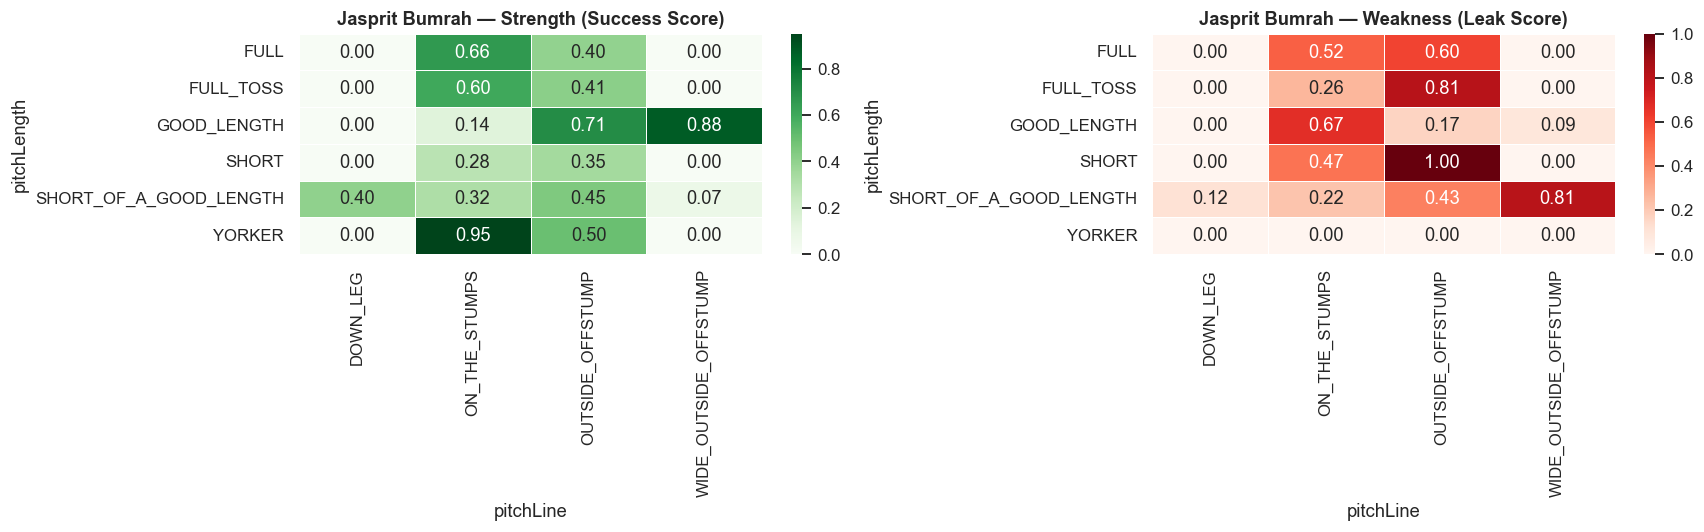

In [10]:
def plot_bowler_zones(name):
    bz  = bowler_zones(name)
    bwz = bowler_weakness_zones(name)
    if bz is None: print(f"No data for {name}"); return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, data, score_col, cmap, title in [
        (axes[0], bz,  'success_score',  'Greens', 'Strength (Success Score)'),
        (axes[1], bwz, 'weakness_score', 'Reds',   'Weakness (Leak Score)')
    ]:
        if data is not None and not data.empty:
            pivot = data.pivot_table(score_col, index='pitchLength', columns='pitchLine').fillna(0)
            sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap, ax=ax, linewidths=0.5)
            ax.set_title(f"{name} — {title}", fontweight='bold')
    plt.tight_layout(); plt.show()

plot_bowler_zones('Jasprit Bumrah')

In [11]:
def plot_bowler_phase(name):
    bps = bowler_phase_stats(name)
    if bps is None: return
    fig = make_subplots(rows=1, cols=3, subplot_titles=['Economy','Wicket %','Dot Ball %'])
    colors = ['#2ecc71','#e67e22','#e74c3c']
    for i, col in enumerate(['economy','wicket_pct','dot_pct'], 1):
        fig.add_trace(go.Bar(x=bps['match_phase'], y=bps[col],
                             marker_color=colors, showlegend=False,
                             text=bps[col], textposition='outside'),
                      row=1, col=i)
    fig.update_layout(title=f"Phase Performance — {name}", height=420)
    fig.show()
plot_bowler_phase('Jasprit Bumrah')

In [12]:
def plot_economy_trend(name):
    et = economy_trend(name)
    if et is None: return
    fig = px.line(et, x='over_int', y='economy', markers=True,
                  title=f"Economy Trend Across Overs — {name}",
                  labels={'over_int':'Over','economy':'Economy Rate'})
    fig.add_hline(y=et['economy'].mean(), line_dash='dot',
                  annotation_text='Overall Average', line_color='gray')
    fig.add_vrect(x0=16, x1=20, fillcolor='lightsalmon', opacity=0.2,
                  layer='below', line_width=0, annotation_text='Death')
    fig.show()
plot_economy_trend('Jasprit Bumrah')

In [13]:
def plot_vs_batting_style(name):
    vbs = bowler_vs_batting_style(name)
    if vbs is None: return
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Economy','Wicket %'])
    colors = ['#3498db','#e74c3c']
    for i, col in enumerate(['economy','wicket_pct'], 1):
        fig.add_trace(go.Bar(x=vbs['Batsman_Batting_Style'], y=vbs[col],
                             marker_color=colors, text=vbs[col],
                             textposition='outside', showlegend=False),
                      row=1, col=i)
    fig.update_layout(title=f"vs LHB vs RHB — {name}", height=400)
    fig.show()
plot_vs_batting_style('Jasprit Bumrah')

In [14]:
def plot_wicket_profile(name):
    wdp = wicket_delivery_profile(name)
    if wdp is None: return
    top = wdp.head(10)
    top['zone_label'] = top['pitchLine'].str[:8] + '\n' + top['pitchLength'].str[:5] + '\n' + top['match_phase'].str[:5]
    fig = px.bar(top, x='zone_label', y='wicket_pct', color='wickets',
                 color_continuous_scale='Reds',
                 title=f"Top Wicket-Taking Zones — {name}",
                 text=top['wickets'], labels={'zone_label':'Zone','wicket_pct':'Wicket %'})
    fig.update_traces(textposition='outside')
    fig.show()
plot_wicket_profile('Jasprit Bumrah')